In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [10]:
raw_data = pd.read_csv("asr_fairness_audio/metadata.tsv", sep='\t')
raw_data.head()

,hash_name,transcription,age,gender,first_language,socioeconomic_bkgd,ethnicity
0,ca1920051b7fdc279c45b5211b261cf0,hey facebook answer the call,18 - 22,female,English,Low,White
1,61b469ebfd9e2ee5ec3295b23d282ec4,hey facebook remove video,31 - 45,female,English,Medium,White
2,eb7e37f0cf0c1b5e3587f2ee6a4bd3ba,i wanna look for hotels for next weekend's vac...,18 - 22,male,English,Low,White
3,d1354340600029ae49d0efac5d1dcb14,hey facebook stop current playing song,18 - 22,male,English,Medium,Black or African American
4,46b92c6d41ef7b63d1f0ccb40bb1d3c5,hey facebook call the last dialed number,31 - 45,male,English,Low,Black or African American


In [3]:
raw_data.groupby(by="gender",as_index=False).count()

,gender,hash_name,transcription,age,first_language,socioeconomic_bkgd,ethnicity
0,female,14422,14421,14422,14422,14422,14422
1,male,12049,12049,12049,12049,12049,12049


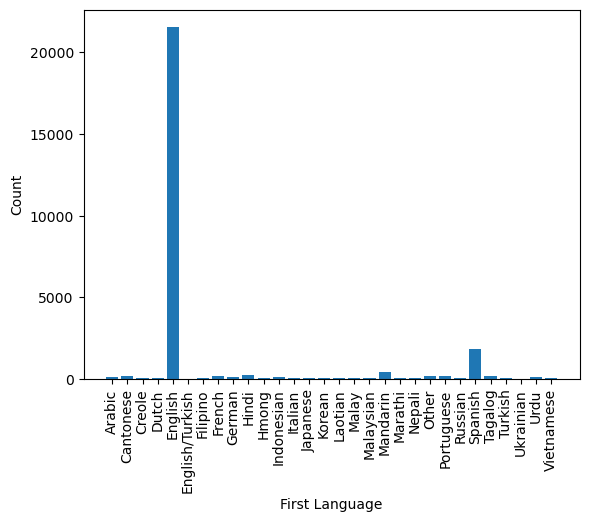

In [4]:
g = raw_data.groupby(by="first_language",as_index=False).count()

fig, ax = plt.subplots(1,1)
ax.bar(np.arange(len(g)), g.hash_name)
ax.set_xticks(np.arange(len(g)), g.first_language, rotation=90)
ax.set_ylabel("Count")
ax.set_xlabel("First Language")
plt.show()

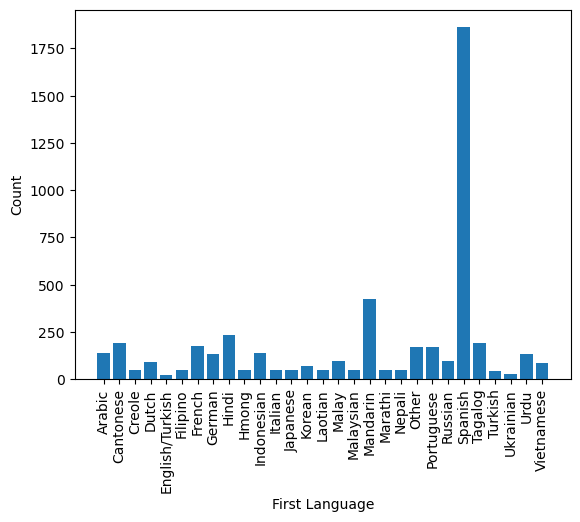

In [5]:
g = raw_data.groupby(by="first_language",as_index=False).count()
g.drop(index=4,inplace=True)

fig, ax = plt.subplots(1,1)
ax.bar(np.arange(len(g)), g.hash_name)
ax.set_xticks(np.arange(len(g)), g.first_language, rotation=90)
ax.set_ylabel("Count")
ax.set_xlabel("First Language")
plt.show()

In [9]:
print("Total # of samples Hindi: ", len(raw_data[raw_data["first_language"]=="Hindi"]))
print("Total # of samples Urdu: ", len(raw_data[raw_data["first_language"]=="Urdu"]))

Total # of samples Hindi:  233
Total # of samples Urdu:  136


In [14]:
import shutil
import os

n_samples = 100

langs = ["English","Hindi","Urdu"]

filename_dict = {l:[] for l in langs}

for l in langs:
    lang_subset = raw_data[raw_data["first_language"]==l]

    # random sample of files
    rand_samp = lang_subset.sample(n_samples)
    files = rand_samp["hash_name"].tolist()
    filename_dict[l] = files

    # save file name and transcription
    rand_samp.to_csv(f"audio_subset/{l}/{l}_metadata.csv")

    # copy files over
    for file in files:
        shutil.copy(f"asr_fairness_audio/{file}.wav", f"audio_subset/{l}/")

In [10]:
# combine subsets together for subset eda
eng_df = pd.read_csv("audio_subset/English/English_metadata.csv").drop(columns=["Unnamed: 0"],inplace=False)
hindi_df = pd.read_csv("audio_subset/Hindi/Hindi_metadata.csv").drop(columns=["Unnamed: 0"],inplace=False)
urdu_df = pd.read_csv("audio_subset/Urdu/Urdu_metadata.csv").drop(columns=["Unnamed: 0"],inplace=False)

sub_df = pd.concat([eng_df, hindi_df, urdu_df], ignore_index=True)
sub_df.to_csv("audio_subset/subset_metadata.csv",index=False)

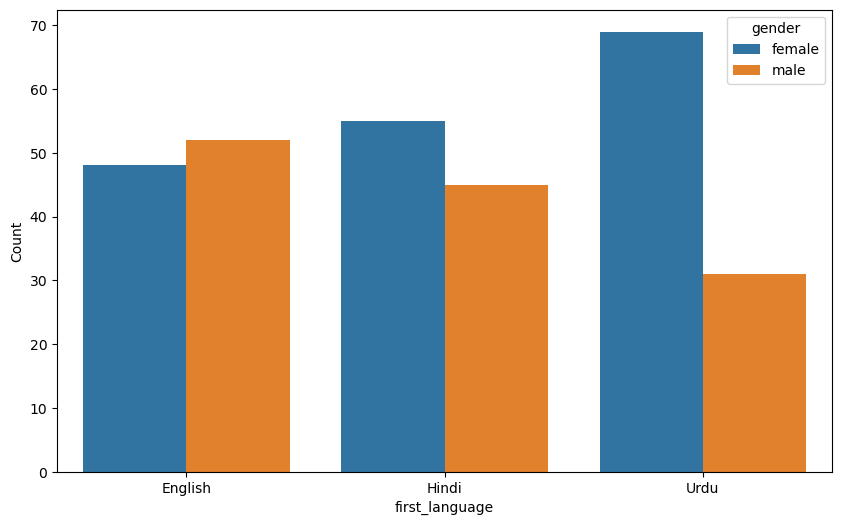

In [21]:
gender_df = sub_df.groupby(by=["gender","first_language"],as_index=False).count()

plt.figure(figsize=(10,6))
sns.barplot(data=gender_df, x="first_language", y="hash_name",hue="gender")
plt.ylabel("Count")
plt.show()

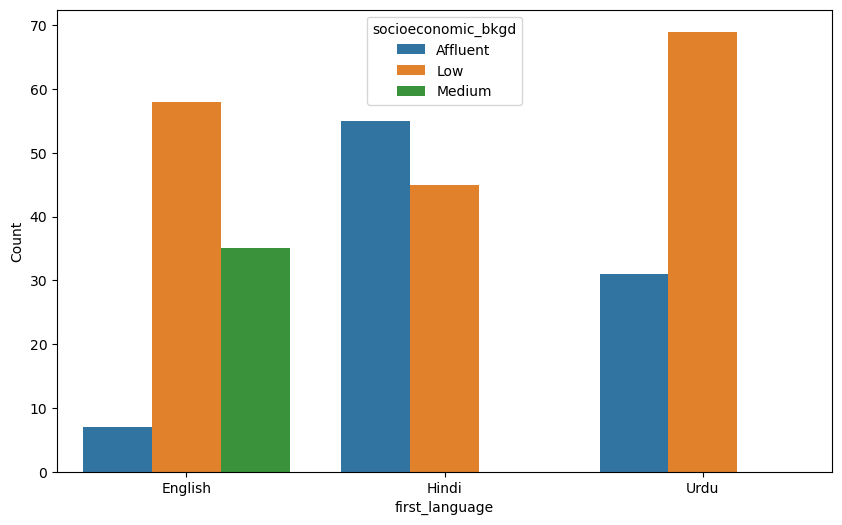

In [20]:
socecon_df = sub_df.groupby(by=["socioeconomic_bkgd","first_language"],as_index=False).count()

plt.figure(figsize=(10,6))
sns.barplot(data=socecon_df, x="first_language", y="hash_name",hue="socioeconomic_bkgd")
plt.ylabel("Count")
plt.show()

(array([163.,  85.,  25.,   9.,  10.,   3.,   3.,   1.,   0.,   1.]),
 array([ 12. ,  52.1,  92.2, 132.3, 172.4, 212.5, 252.6, 292.7, 332.8,
        372.9, 413. ]),
 <BarContainer object of 10 artists>)

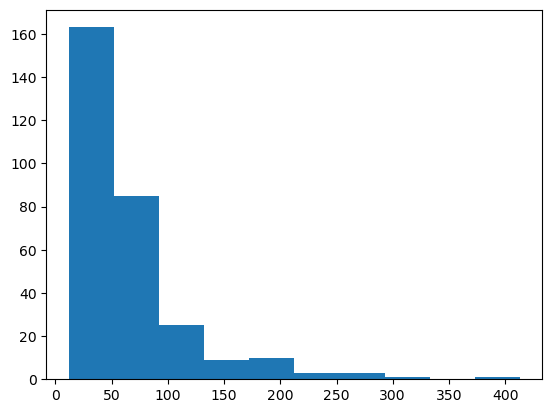

In [29]:
sub_df["trans_len"] = [len(t) for t in sub_df.transcription]
sub_df.sort_values(by="trans_len",ascending=False,inplace=True)

plt.hist(sub_df.trans_len)

In [ ]:
# calculate audio duration
import wave
import contextlib

def get_audio_dur(file_path):
    with contextlib.closing(wave.open(file_path, 'r')) as f:
        frames = f.getnframes()
        rate = f.getframerate()
        duration = frames / float(rate)
        return duration

sub_df = pd.read_csv("audio_subset/subset_metadata.csv")
sub_df["audio_dur"] = [get_audio_dur(f"asr_fairness_audio/{f}.wav") for f in sub_df.hash_name]

(array([205.,  59.,  25.,   6.,   2.,   1.,   1.,   0.,   0.,   1.]),
 array([ 1.92     ,  7.9807625, 14.041525 , 20.1022875, 26.16305  ,
        32.2238125, 38.284575 , 44.3453375, 50.4061   , 56.4668625,
        62.527625 ]),
 <BarContainer object of 10 artists>)

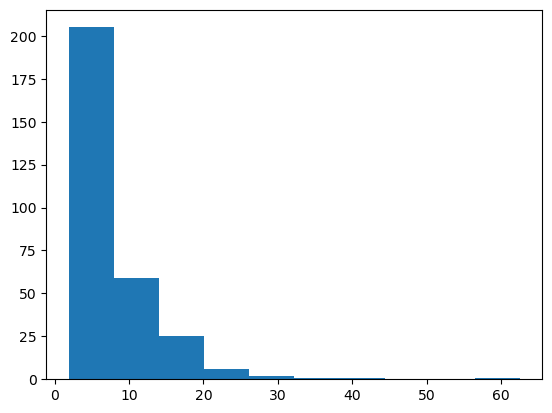

In [7]:
plt.hist(sub_df["audio_dur"])

In [9]:
sub_df.sort_values("audio_dur",ascending=False)

,hash_name,transcription,age,gender,first_language,socioeconomic_bkgd,ethnicity,audio_dur
94,3daf401c6f3212ad25f1d632f3a04390,turn on surround sound turn the volume down tu...,46 - 65,female,English,Low,Black or African American,62.527625
232,9354446bd6fd89b0d21fbf40d9207514,hi dear i am very much frustrated about these ...,31 - 45,female,Urdu,Low,"Asian, South Asian or Asian American",40.426313
158,646476ccb1600967617ac069225bd38d,hi love i was just talking to my friend and we...,31 - 45,female,Hindi,Affluent,"Asian, South Asian or Asian American",33.407625
92,54f999c8833022f986e79c51a085592f,reply back to george the second saying hey ran...,31 - 45,male,English,Low,"Hispanic, Latino, or Spanish",29.247625
249,1485f39500388c731f2f432884e7e6db,hi you just called me and i was really shocked...,31 - 45,female,Urdu,Low,"Asian, South Asian or Asian American",28.821000
...,...,...,...,...,...,...,...,...
279,7381ffa6f9c03559d311c69a10b40942,stop playing,46 - 65,female,Urdu,Low,"Asian, South Asian or Asian American",3.080000
58,943e02c81634afdaf66465de2f8cfdea,pause the music,31 - 45,female,English,Medium,White,3.080000
75,63f32772868848fc54edf09931d281b3,hey facebook end call,18 - 22,female,English,Low,"Hispanic, Latino, or Spanish",2.858312
13,dbafbbb1c9f14572eec23326c6afb00a,hey facebook play back music,31 - 45,female,English,Low,"Native American, American Indian, or Alaska Na...",2.720000


In [11]:
# replace sample that is too long
eng_fnames = sub_df[sub_df["first_language"]=="English"]["hash_name"].tolist()

new_files = raw_data.sample(20)
for n in new_files.hash_name:
    if n in eng_fnames:
        print(f"ignore {n}")

In [15]:
sub_df.loc[94] = new_files.iloc[0]

In [18]:
sub_df.to_csv("audio_subset/subset_metadata.csv",index=False)

In [20]:
import shutil
shutil.copy("asr_fairness_audio/b473df3459cbdb3a6f52aeb8fc4ffa04.wav", "audio_subset/")

'audio_subset/b473df3459cbdb3a6f52aeb8fc4ffa04.wav'